In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
from sklearn import model_selection
from sklearn import preprocessing 
from sklearn import metrics

In [3]:
from tensorflow.keras.layers import InputLayer, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam 

2026-09-08 12:21:49.906983: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-08 12:21:50.437706: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-08 12:21:50.577850: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-09-08 12:21:50.577887: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not ha

In [4]:
import joblib

# 1.Učitavanje i priprema podataka

In [5]:
data = pd.read_csv('../data/online_shoppers_intention.csv')

In [6]:
data['Revenue'] = data['Revenue'].astype(int)
data['Weekend'] = data['Weekend'].astype(int)

In [7]:
data = pd.get_dummies(data, columns=['Month', 'VisitorType'], drop_first=True)

Za razliku od Random Forest modela, kod neuronske mreže neophodan je i one-hot encoding kategoričkih promenljivih Month i VisitorType. 

data.info()

In [8]:
x = data.drop(['Revenue'], axis=1)
y = data['Revenue']

In [9]:
x.shape

(12330, 26)

In [10]:
y.shape

(12330,)

# 2. Podela podataka 

In [11]:
x_train_validation, x_test, y_train_validation, y_test = model_selection.train_test_split(x,y, test_size=0.33, stratify=y, random_state=7)
x_train, x_validation, y_train, y_validation = model_selection.train_test_split(x_train_validation, y_train_validation, train_size=0.8, stratify=y_train_validation, random_state=7)

In [12]:
x_train.shape

(6608, 26)

In [13]:
x_validation.shape

(1653, 26)

In [14]:
x_test.shape

(4069, 26)

# 3. Standardizacija 

In [15]:
scaler = preprocessing.StandardScaler()

Standardizacija numeričkih atributa je važna jer neuronska mreža množi ulazne vrednosti sa težinama, pa velike razlike u sklama atributa mogu uticati na stabilnost i brzinu treniranja modela. Standardizacijom se atributi svode na približno istu skalu, čime se omogućava efikasnije i stabilnije učenje. 

In [16]:
scaler.fit(x_train)

StandardScaler()

In [17]:
x_train = scaler.transform(x_train)
x_validation = scaler.transform(x_validation)
x_test = scaler.transform(x_test)

In [18]:
feature_names = x.columns
number_of_features = feature_names.shape[0]
output_size = 1

Scaler je treniran (fit) na trening skupu, a zatim primenjen (transform) na podacima.

# 4. Model 1 

Model 1 predstavlja najjednostavniju arhitekturu - jedan skriveni skloj sa 32 neurona. Ovaj model predstavlja osnovni model za poređenje sa složenijim arhitekturama 2 i 3. 

In [19]:
model1 = Sequential()
model1.add(InputLayer(input_shape=(number_of_features, )))
model1.add(Dense(32, activation='relu'))
model1.add(Dense(output_size, activation='sigmoid'))

2026-09-08 12:21:53.129050: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-09-08 12:21:53.129711: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2026-09-08 12:21:53.129739: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (milena-Vostro-15-3530): /proc/driver/nvidia/version does not exist
2026-09-08 12:21:53.131267: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [20]:
model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                864       
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 897
Trainable params: 897
Non-trainable params: 0
_________________________________________________________________


Model ima ukupno 897 parametara, što je znatno manje u odnosu na arhitekture koje slede. U nastavku će biti ispitivano da li dodatna kompleksnost mreže donosi poboljšanje na ovom skupu podataka. 

In [21]:
model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['AUC'])

In [22]:
history1 = model1.fit(x_train, y_train, epochs=50, batch_size=32, validation_data=(x_validation, y_validation), verbose=1)

Epoch 1/50
207/207 [==============================] - 1s 2ms/step - loss: 0.4759 - auc: 0.6140 - val_loss: 0.3552 - val_auc: 0.7967
Epoch 2/50
207/207 [==============================] - 0s 1ms/step - loss: 0.3230 - auc: 0.8397 - val_loss: 0.3065 - val_auc: 0.8577
Epoch 3/50
207/207 [==============================] - 0s 1ms/step - loss: 0.2904 - auc: 0.8792 - val_loss: 0.2894 - val_auc: 0.8768
Epoch 4/50
207/207 [==============================] - 0s 1ms/step - loss: 0.2767 - auc: 0.8938 - val_loss: 0.2809 - val_auc: 0.8830
Epoch 5/50
207/207 [==============================] - 0s 1ms/step - loss: 0.2679 - auc: 0.9024 - val_loss: 0.2733 - val_auc: 0.8911
Epoch 6/50
207/207 [==============================] - 0s 1ms/step - loss: 0.2614 - auc: 0.9078 - val_loss: 0.2700 - val_auc: 0.8935
Epoch 7/50
207/207 [==============================] - 0s 858us/step - loss: 0.2562 - auc: 0.9111 - val_loss: 0.2659 - val_auc: 0.8965
Epoch 8/50
207/207 [==============================] - 0s 1ms/step - loss: 

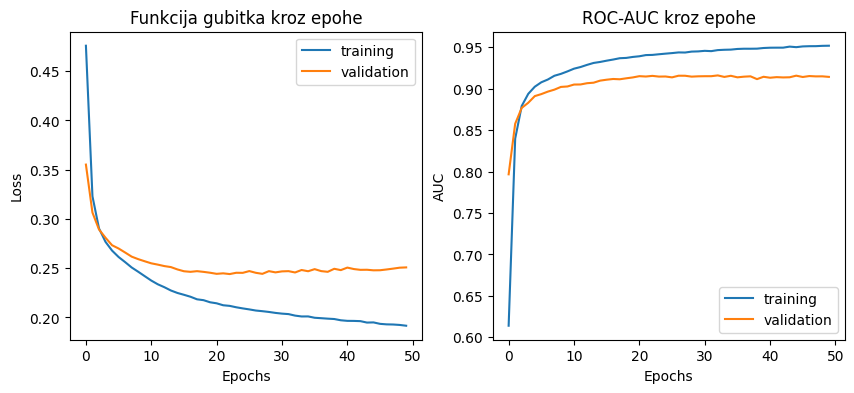

In [23]:
plt.figure(figsize=(10,4))

plt.subplot(121)
plt.plot(history1.history['loss'], label='training')
plt.plot(history1.history['val_loss'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Funkcija gubitka kroz epohe')
plt.legend(loc='best')

plt.subplot(122)
plt.plot(history1.history['auc'], label='training')
plt.plot(history1.history['val_auc'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.title('ROC-AUC kroz epohe')
plt.legend(loc='best')

plt.show()

Levi grafik prikazuje kretanje funkcije gubitka (binary crossentropy) kroz epohe treniranja, odvojeno za trening i validacioni skup, dok desni grafik prikazuje odgovarajuće kretanje ROC-AUC mere. Na oba grafika trening kriva se poboljšava tokom celog treniranja, gubitak opada, a ROC-AUC raste, a validaciona kriva dostiže svoj optimum znatno ranije - oko 15.-20.epohe nakon čega sragnira ili se blago pogoršava. Ova razlika između trening i validacione krive predstavlja klasičan pokazatelj blagog preprilagođavanja. 

In [24]:
train_scores = model1.evaluate(x_train, y_train, batch_size=32)
train_scores

207/207 [==============================] - 0s 462us/step - loss: 0.1896 - auc: 0.9547


[0.1895843893289566, 0.9547001123428345]

In [25]:
test_scores = model1.evaluate(x_test, y_test, batch_size=32)
test_scores

128/128 [==============================] - 0s 698us/step - loss: 0.2632 - auc: 0.9099


[0.2632153034210205, 0.9099170565605164]

In [26]:
y_test_prob = model1.predict(x_test).ravel()
y_test_prob

128/128 [==============================] - 0s 326us/step


array([0.00604525, 0.0442471 , 0.05811295, ..., 0.01487631, 0.01288008,
       0.00018734], dtype=float32)

In [27]:
y_test_predicted = (y_test_prob >= 0.5).astype(int)

In [28]:
print(metrics.confusion_matrix(y_test, y_test_predicted))

[[3299  140]
 [ 296  334]]


In [29]:
print(metrics.classification_report(y_test, y_test_predicted))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      3439
           1       0.70      0.53      0.61       630

    accuracy                           0.89      4069
   macro avg       0.81      0.74      0.77      4069
weighted avg       0.88      0.89      0.89      4069



In [30]:
roc_auc_model1 = metrics.roc_auc_score(y_test, y_test_prob)
roc_auc_model1

0.9097144334131829

In [31]:
accuracy_model1 = metrics.accuracy_score(y_test, y_test_predicted)
accuracy_model1 

0.8928483656918161

In [32]:
precision_model1 = metrics.precision_score(y_test, y_test_predicted)
precision_model1

0.7046413502109705

In [33]:
recall_model1 = metrics.recall_score(y_test, y_test_predicted)
recall_model1

0.5301587301587302

In [34]:
f1_model1 = metrics.f1_score(y_test, y_test_predicted)
f1_model1

0.605072463768116

Model sa jednim skrivenim slojem od 32 neurona je ostvario na test skupu ROC-AUC od 0,908, a na trening skupu 0,953. Poređenjem trening i test AUC vrednosti uočava se umeren razmak koji ukazuje na blagi stepen preprilagođavanja. Ovo se potvrđuje i grafikom funkcije gubitka, gde validacioni gubitak počinje blago da raste nakon otprilike 15-20 epoha, dok trening gubitak nastavlja da opada.

# 5. Model 2

Model 2 dodaje drugi skriveni sloj, bez ikakve regularizacione tehnike, sa ciljem da se ispiza da li povećanje kapaciteta mreže samo po sebi poboljšava performanse. 

In [35]:
model2 = Sequential()
model2.add(InputLayer(input_shape=(number_of_features, )))
model2.add(Dense(64, activation='relu'))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(output_size, activation='sigmoid'))

In [36]:
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 64)                1728      
                                                                 
 dense_3 (Dense)             (None, 32)                2080      
                                                                 
 dense_4 (Dense)             (None, 1)                 33        
                                                                 
Total params: 3,841
Trainable params: 3,841
Non-trainable params: 0
_________________________________________________________________


In [37]:
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['AUC'])

In [38]:
history2 = model2.fit(x_train, y_train, validation_data=(x_validation, y_validation), epochs=50, batch_size=32, verbose=1)

Epoch 1/50
207/207 [==============================] - 1s 2ms/step - loss: 0.3304 - auc: 0.8264 - val_loss: 0.2899 - val_auc: 0.8768
Epoch 2/50
207/207 [==============================] - 0s 1ms/step - loss: 0.2648 - auc: 0.9028 - val_loss: 0.2759 - val_auc: 0.8922
Epoch 3/50
207/207 [==============================] - 0s 1ms/step - loss: 0.2492 - auc: 0.9154 - val_loss: 0.2632 - val_auc: 0.8970
Epoch 4/50
207/207 [==============================] - 0s 1ms/step - loss: 0.2364 - auc: 0.9238 - val_loss: 0.2600 - val_auc: 0.8989
Epoch 5/50
207/207 [==============================] - 0s 1ms/step - loss: 0.2297 - auc: 0.9287 - val_loss: 0.2544 - val_auc: 0.9033
Epoch 6/50
207/207 [==============================] - 0s 1ms/step - loss: 0.2233 - auc: 0.9331 - val_loss: 0.2552 - val_auc: 0.9051
Epoch 7/50
207/207 [==============================] - 0s 1ms/step - loss: 0.2175 - auc: 0.9369 - val_loss: 0.2514 - val_auc: 0.9079
Epoch 8/50
207/207 [==============================] - 0s 2ms/step - loss: 0.

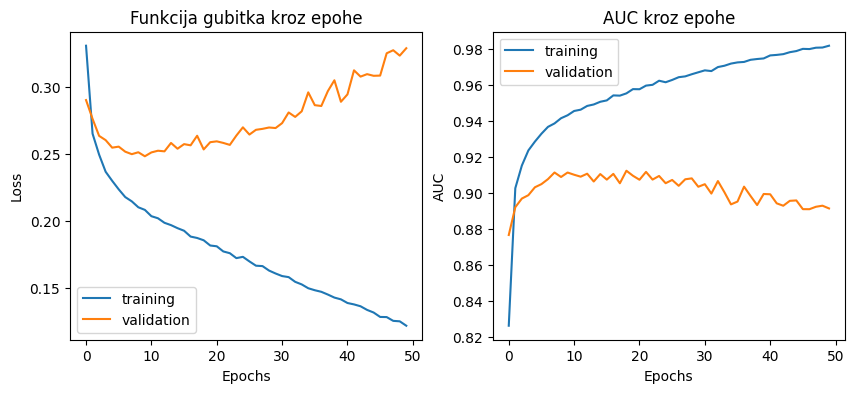

In [39]:
plt.figure(figsize=(10,4))

plt.subplot(121)
plt.plot(history2.history['loss'], label='training')
plt.plot(history2.history['val_loss'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Funkcija gubitka kroz epohe')
plt.legend(loc='best')

plt.subplot(122)
plt.plot(history2.history['auc'], label='training')
plt.plot(history2.history['val_auc'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.title('AUC kroz epohe')
plt.legend(loc='best')
plt.show()

Model 2 znatno je podložniji preprilagođavanju od jednostavnijeg modela 1. Razmak između trening i validacione krive na oba grafika je mnogo veći, što ukazuje da dodatni kapacitet mreže omogućava modelu da uči specifičnosti trening skupa umesto da genralizuje. 

In [40]:
train_scores = model2.evaluate(x_train, y_train, batch_size=32)
train_scores

207/207 [==============================] - 0s 642us/step - loss: 0.1140 - auc: 0.9843


[0.11395016312599182, 0.9843482971191406]

In [41]:
test_scores = model2.evaluate(x_test, y_test, batch_size=32)
test_scores

128/128 [==============================] - 0s 734us/step - loss: 0.3639 - auc: 0.8776


[0.3639073073863983, 0.8775927424430847]

In [42]:
y_test_prob = model2.predict(x_test).ravel()
y_test_prob

128/128 [==============================] - 0s 438us/step


array([2.7909249e-05, 2.4524789e-02, 3.2050383e-01, ..., 2.2316440e-03,
       3.8564187e-05, 1.3832857e-04], dtype=float32)

In [43]:
y_test_predicted = (y_test_prob >= 0.5).astype(int)

In [44]:
print(metrics.confusion_matrix(y_test, y_test_predicted))

[[3251  188]
 [ 286  344]]


In [45]:
print(metrics.classification_report(y_test, y_test_predicted))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93      3439
           1       0.65      0.55      0.59       630

    accuracy                           0.88      4069
   macro avg       0.78      0.75      0.76      4069
weighted avg       0.88      0.88      0.88      4069



In [46]:
roc_auc_model2 = metrics.roc_auc_score(y_test, y_test_prob)
roc_auc_model2

0.890864130861223

In [47]:
accuracy_model2 = metrics.accuracy_score(y_test, y_test_predicted)
accuracy_model2

0.8835094617842222

In [48]:
precision_model2 = metrics.precision_score(y_test, y_test_predicted)
precision_model2

0.6466165413533834

In [49]:
recall_model2 = metrics.recall_score(y_test, y_test_predicted)
recall_model2

0.546031746031746

In [50]:
f1_model2 = metrics.f1_score(y_test, y_test_predicted)
f1_model2

0.5920826161790017

Dodavanjem drugog skrivenog sloja, model je ostvario nešto slabije rezultate od modela 1. Razmak između trening i test AUC je znatno izraženiji nego kod modela 1, što ukazuje na preprilagođavanje. Model sa više parametara je počeo da "pamti" specifičnosti trening skupa umesto da uči generalne obrasce.

Ovaj rezultat pokazuje da prosto povećanje broja slojeva ili neurona u slojevima, bez odgovarajuće regularizacije, ne dovodi automatski do boljih performansi, već čak može i pogoršati generalizaciju modela.

# 6. Model 3

Model 3 predstavlja najsloženiju arhitekturu, uz primenu Dropout slojeva od 0.3 i 0.2 kao regularizacione tehnike kojom se nasumično isključuje deo neurona tokom treniranja radi sprečavanja preprilagođavanja karakterističnog za duboke mreže. 

In [51]:
model3 = Sequential()
model3.add(InputLayer(input_shape=(number_of_features, )))
model3.add(Dense(128, activation='relu'))
model3.add(Dropout(0.3))
model3.add(Dense(64, activation='relu'))
model3.add(Dropout(0.2))
model3.add(Dense(32, activation='relu'))
model3.add(Dense(output_size, activation='sigmoid'))

In [52]:
model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['AUC'])

In [53]:
history3 = model3.fit(x_train, y_train, validation_data=(x_validation, y_validation), epochs=50, batch_size=32, verbose=1)

Epoch 1/50
207/207 [==============================] - 1s 2ms/step - loss: 0.3531 - auc: 0.7953 - val_loss: 0.2750 - val_auc: 0.8866
Epoch 2/50
207/207 [==============================] - 0s 2ms/step - loss: 0.2793 - auc: 0.8836 - val_loss: 0.2601 - val_auc: 0.8999
Epoch 3/50
207/207 [==============================] - 0s 1ms/step - loss: 0.2650 - auc: 0.8986 - val_loss: 0.2549 - val_auc: 0.9070
Epoch 4/50
207/207 [==============================] - 0s 2ms/step - loss: 0.2500 - auc: 0.9089 - val_loss: 0.2500 - val_auc: 0.9094
Epoch 5/50
207/207 [==============================] - 0s 1ms/step - loss: 0.2447 - auc: 0.9148 - val_loss: 0.2457 - val_auc: 0.9161
Epoch 6/50
207/207 [==============================] - 0s 2ms/step - loss: 0.2416 - auc: 0.9161 - val_loss: 0.2437 - val_auc: 0.9157
Epoch 7/50
207/207 [==============================] - 0s 1ms/step - loss: 0.2341 - auc: 0.9232 - val_loss: 0.2407 - val_auc: 0.9182
Epoch 8/50
207/207 [==============================] - 0s 2ms/step - loss: 0.

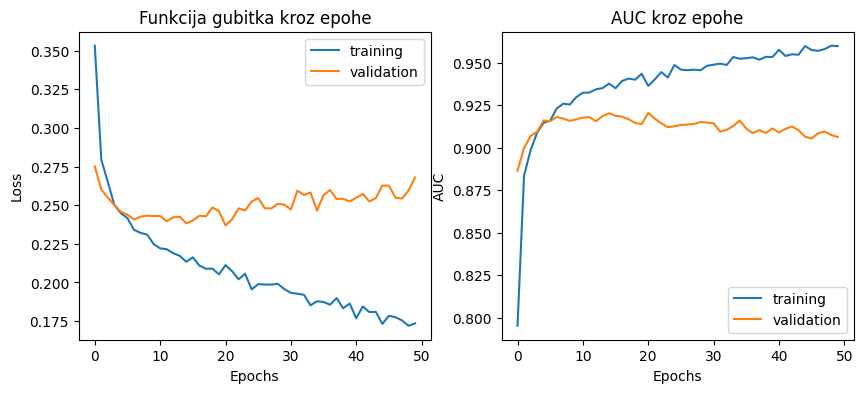

In [54]:
plt.figure(figsize=(10,4))

plt.subplot(121)
plt.plot(history3.history['loss'], label='training')
plt.plot(history3.history['val_loss'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Funkcija gubitka kroz epohe')
plt.legend(loc='best')

plt.subplot(122)
plt.plot(history3.history['auc'], label='training')
plt.plot(history3.history['val_auc'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.title('AUC kroz epohe')
plt.legend(loc='best')
plt.show()

U poređenju sa modelom 2, jasno se vidi da je uvođenje Dropout slojeva uspešno smanjilo razmak između trening i validacionih performansi. Iako je model 3 znatno kompleksniji regularizacija mu je omogućila da postigne stabilniju generalizaciju uz AUC uporediv sa modelom 1. 

In [55]:
train_scores = model3.evaluate(x_train, y_train, batch_size=32)
train_scores

207/207 [==============================] - 0s 1ms/step - loss: 0.1371 - auc: 0.9763


[0.1370774209499359, 0.9763138890266418]

In [56]:
test_scores = model3.evaluate(x_test, y_test, batch_size=32)
test_scores

128/128 [==============================] - 0s 855us/step - loss: 0.2926 - auc: 0.9015


[0.29263782501220703, 0.9014832973480225]

In [57]:
y_test_prob = model3.predict(x_test).ravel()
y_test_prob

128/128 [==============================] - 0s 1ms/step


array([0.00026837, 0.03857694, 0.06961928, ..., 0.01197135, 0.00029618,
       0.00012553], dtype=float32)

In [58]:
y_test_predicted = (y_test_prob >= 0.5).astype(int)

In [59]:
print(metrics.confusion_matrix(y_test, y_test_predicted))

[[3287  152]
 [ 300  330]]


In [60]:
print(metrics.classification_report(y_test, y_test_predicted))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      3439
           1       0.68      0.52      0.59       630

    accuracy                           0.89      4069
   macro avg       0.80      0.74      0.76      4069
weighted avg       0.88      0.89      0.88      4069



In [61]:
roc_auc_model3 = metrics.roc_auc_score(y_test, y_test_prob)
roc_auc_model3 

0.9079542779600936

In [62]:
accuracy_model3 = metrics.accuracy_score(y_test, y_test_predicted)
accuracy_model3 

0.8889161956254608

In [63]:
precision_model3 = metrics.precision_score(y_test, y_test_predicted)
precision_model3

0.6846473029045643

In [64]:
recall_model3 = metrics.recall_score(y_test, y_test_predicted)
recall_model3

0.5238095238095238

In [65]:
f1_model3 = metrics.f1_score(y_test, y_test_predicted)
f1_model3

0.5935251798561151

Najsloženija arhitektura ostvarila je ROC-AUC praktično identičan modelu 1. Razlika između trening i test AUC je manja nego kod modela 2, što potvrđuje da je Dropout uspešno ublažio preprilagođavanje koje se javilo u modelu 2.

Model 3 ostvaruje najvišu F1 meru od sva tri modela. 

Ipak, s obzirom na to da su ROC-AUC vrednosti modela 1 i modela 3 gotovo identične, dodatna složenost i duže vreme treniranja modela 3 ne donose suštinsko poboljšanje performansi na ovm skupu podataka. 

# 7. Poređenje i izbor najboljeg modela

In [66]:
rezultati = pd.DataFrame({
    'Model' : ['Model 1', 'Model 2', 'Model 3'],
    'Accuracy' : [accuracy_model1, accuracy_model2, accuracy_model3],
    'Precision': [precision_model1, precision_model2, precision_model3],
    'Recall' : [recall_model1, recall_model2, recall_model3],
    'F1-score' : [f1_model1, f1_model2, f1_model3],
    'ROC-AUC' : [roc_auc_model1, roc_auc_model2, roc_auc_model3]
})

rezultati = rezultati.round(4)
print(rezultati)

     Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0  Model 1    0.8928     0.7046  0.5302    0.6051   0.9097
1  Model 2    0.8835     0.6466  0.5460    0.5921   0.8909
2  Model 3    0.8889     0.6846  0.5238    0.5935   0.9080


Tabela objedinjuje sve mere kvaliteta za prethodne tri arhitekture, na osnovu kojih se u nastavku vizuelno i brojčano porede njihove performanse i bira finalni model.

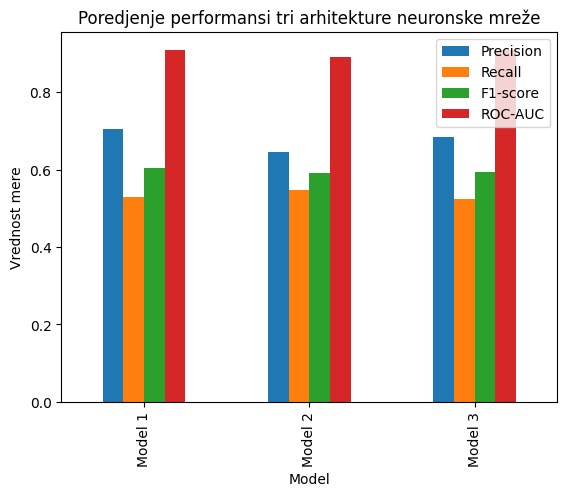

In [67]:
rezultati.set_index('Model')[['Precision', 'Recall', 'F1-score', 'ROC-AUC']].plot(kind='bar')
plt.title('Poredjenje performansi tri arhitekture neuronske mreže')
plt.ylabel('Vrednost mere')
plt.legend(loc='best')
plt.show()

In [68]:
best_model_ind = np.argmax(rezultati['ROC-AUC'])
best_model = rezultati.loc[best_model_ind, 'Model']

print(f'Najbolji model po meri ROC-AUC je {best_model}')
print(rezultati.loc[best_model_ind])

Najbolji model po meri ROC-AUC je Model 1
Model        Model 1
Accuracy      0.8928
Precision     0.7046
Recall        0.5302
F1-score      0.6051
ROC-AUC       0.9097
Name: 0, dtype: object


Model 1, odnosno najjednostavniji model i Model 3, najsloženiji model, dostižu skoro identičan ROC-AUC. Dolazi se do zaključka da dodatna dubina mreže na modelu 3 ne donosi suštinsko poboljšanje u odnosu na jednostavnu arhitekturu sa samo jednim skrivenim slojem, uprkos tome što ima 4 puta više parametara. Dropout je u modelu 3 uspešno sprečio overfitting, ali krajnji rezultat i dalje ne prevazilazi jednostavniji model.

Model 2 je najslabiji. Ovo dokazuje da dodatni sloj bez korišćenja Dropout-a, dovodi do umerenog preprilagođavanja koji šteti generalizaciji.

Po F1 meri, model 3 je blago bolji zahvaljujući blago boljem odzivu.

Kao najbolji model se bira model 1. Iako modeli 1 i 3 postižu suštinski iste rezultate, model 1 uz manje parametara i brže treniranje postiže bolje rezultate i manji rizik od preprilagođavanja na novim podacima. 

# 8. Čuvanje modela i scalera 

In [69]:
modeli_dict = {'Model 1':model1, 'Model 2': model2, 'Model 3': model3}
modeli_dict[best_model].save('../models/04-NNetwork.keras')

In [70]:
joblib.dump(scaler, '../models/04-Scaler.pkl')

['../models/04-Scaler.pkl']